# FHRS Rating Banding Modelling

This notebook details regression model builds and testing for FSA Hygiene Rating bandings. Initial decisions / approach are below:

#### Rating Bandings

As decided in `./01_data_exploration.ipynb`, I will initially target a three-tier banding (`critical`/`fail`/`pass`), with a binary fallback (`<=2`, or `<5`) if the first approach doesn't hold up.  

#### Features

As decided in `./04_imd_domain_join.ipynb`, I will use two LSOA-linked (location) deprivation factors: `income_decile` and `crime_decile`, from the domain-level IMD 2025 dataset. Overall `imd_decile` will be used as a fallback if needed.   

From the raw dataset, I have chosen to include:
- `BusinessType` - a clear candidate and a natural feature, with obvious impacts on an establishment's operation and therefore risk profile.  
- `LocalAuthorityName` - while this will already be somewhat represented through the deprivation deciles, local factors within a borough can vary wildly. For example, Tower Hamlets contains extremes in Canary Wharf (affluent, highly developed) and Whitechapel (among the most deprived neighbourhoods in London). Different borough Local Authorities may have different Food Safety initiatives or support, which again could impact likely ratings.    

#### Class-weight balancing

The requirement for class-weight balancing during modelling was identified during data cleaning, where the critical tier was found to represent only ~5.6% of gradable establishments London-wide.

#### Regression Model Type

I will use a **standard multinomial logistic regression** as my initial model: this is a relatively simple, well-proven and well-documented model, with built-in class balancing support (`sklearn`'s `LogisticRegression` has `class_weight="balanced"`). Notably, it treats the three rating tiers as unordered categories. The need for class weight balancing was identified in the initial data exploration notebook.   

An alternative (possibly secondary) approach is to use an **ordinal logistic regression**: this treats the three tiers as having an order (`critical < fail < pass`), in line with the real-world application of FHRS rating bands. While this is perhaps the more 'statistically correct' fit, the model assumes that each feature's effect is the same size at every threshold, e.g. the Income decile affects the critical -> fail boundary by the same magnitude as the fail -> pass boundary; this is not guaranteed to be true. In addition, `statsmodels`' `OrderedModel` may not handle class weighting as cleanly, which may in turn require manual workarounds.  

On the basis that a standard multinomial is 'safer' from a class-weight balancing aspect, I will use this approach first to get a working baseline, and will then consider trying (and comparing) an ordinal regression afterwards.  

### Data loading & modelling population build

First I will load and check the latest dataset. 

I will then extract the modelling population (establishments with a gradable rating and matching IMD-domain decile data) and build the required additional rating / rating tier columns:

In [1]:
# load data, build modelling DF
import pandas as pd

df = pd.read_csv(
    "../data/processed/fsa_london_establishments_with_domains.csv",
    dtype={"PostCode": str, "postcode_tier": str, "lsoa21cd": str, "RightToReply": str}
)

print(df.shape) # should be (81217, 40)

# same population as the domains notebook: gradable rating + matched deprivation data
model_df = df[
    df["RatingValue"].isin(["0","1","2","3","4","5"]) &
    df["income_decile"].notna() &
    df["crime_decile"].notna()
].copy()

# add required columns
model_df["rating_int"] = model_df["RatingValue"].astype(int)
model_df["tier"] = pd.cut(
    model_df["rating_int"],
    bins=[-1, 2, 4, 5],
    labels=["critical", "fail", "pass"],
)

print(len(model_df)) # should be 63,409
print(model_df["tier"].value_counts())

(81217, 40)
63409
tier
pass        42331
fail        17215
critical     3863
Name: count, dtype: int64


-> expected values confirming there has been no drift.  

I'll check category sizes again for `BusinessType` and `LocalAuthorityName` before turning them into dummy columns, in order to see how thin the rarest categories are within the _modelling-specific_ population:  

In [2]:
# check category sizes for one-hot encoding dummy cols
print(model_df["BusinessType"].value_counts())
print()
print(model_df["LocalAuthorityName"].value_counts().tail(10))

BusinessType
Restaurant/Cafe/Canteen                  23998
Retailers - other                        12650
Takeaway/sandwich shop                    8240
Caring Premises                           4057
Pub/bar/nightclub                         3663
School/college/university                 3165
Other catering premises                   2664
Retailers - supermarkets/hypermarkets     2219
Hotel/bed & breakfast/guest house          926
Mobile caterer                             737
Manufacturers/packers                      640
Distributors/Transporters                  355
Importers/Exporters                         84
Farmers/growers                             11
Name: count, dtype: int64

LocalAuthorityName
Haringey                1614
Redbridge               1505
Havering                1360
Harrow                  1330
Bexley                  1307
Richmond-Upon-Thames    1233
Kingston-Upon-Thames    1139
Sutton                  1059
Merton                  1041
Barking and Dagenham  

-> Local Authority shows no issues, however when looking at Business Type:

The tail of this category is a concern, with the low counts for Farmers/growers (11 rows), Importers/Exporters (84 rows) and Distributors/Transporters (355 rows) likely to yield zero or near-zero examples of establishments in the 'critical' tier.  

What this potentially means is that the model can't estimate a stable coefficient from a dummy column, resulting in unstable or exaggerated results.  

In order to define a cutoff:

In [3]:
# check Business Type tier representation:
tier_by_type = pd.crosstab(model_df["BusinessType"], model_df["tier"])
print(tier_by_type)

tier                                   critical  fail   pass
BusinessType                                                
Caring Premises                              79   580   3398
Distributors/Transporters                    11    63    281
Farmers/growers                               0     4      7
Hotel/bed & breakfast/guest house            26   150    750
Importers/Exporters                           4    16     64
Manufacturers/packers                        39   138    463
Mobile caterer                               38   201    498
Other catering premises                      93   575   1996
Pub/bar/nightclub                           138   787   2738
Restaurant/Cafe/Canteen                    1490  6624  15884
Retailers - other                          1203  4487   6960
Retailers - supermarkets/hypermarkets        57   313   1849
School/college/university                    33   308   2824
Takeaway/sandwich shop                      652  2969   4619


-> tier counts by Business Type confirms this risk

In order to defend against this risk, I will look to collapse rare categories into an 'Other' banding where a minimum critical rating (i.e. the rarest tier) count is not met:

In [4]:
# collapse rare (critical count) categories into 'Other':

MIN_CRITICAL_COUNT = 15 # slightly stricter than the loose '10 events per variable' rule

critical_counts = tier_by_type["critical"] # count critical ratings, not total rows
rare_types = critical_counts[critical_counts < MIN_CRITICAL_COUNT].index.tolist() 
    # those that do not meet the threshold set above

print(f"Business types to collapse into 'Other': {rare_types}")

# new DF from original, but swaps BusinessType value with "Other" when in rare_types
model_df["BusinessTypeGrouped"] = model_df["BusinessType"].replace(
    dict.fromkeys(rare_types, "Other")
        # assemble dict: {"Farmers/growers": "Other", "Importers/Exporters": "Other", ...}
    # .replace() then takes assembled dict and any keys found in BusinessType are replaced
)

print(model_df["BusinessTypeGrouped"].value_counts())

Business types to collapse into 'Other': ['Distributors/Transporters', 'Farmers/growers', 'Importers/Exporters']
BusinessTypeGrouped
Restaurant/Cafe/Canteen                  23998
Retailers - other                        12650
Takeaway/sandwich shop                    8240
Caring Premises                           4057
Pub/bar/nightclub                         3663
School/college/university                 3165
Other catering premises                   2664
Retailers - supermarkets/hypermarkets     2219
Hotel/bed & breakfast/guest house          926
Mobile caterer                             737
Manufacturers/packers                      640
Other                                      450
Name: count, dtype: int64


-> 'Other' group implemented via the new `BusinessTypeGrouped` column.

Notably,`Distributors/Transporters` narrowly passes a `MIN_CRITICAL_COUNT` of 10 (with 11 critical-tier ratings in its category). As it was on the edge of the initial threshold, and of a broadly similar operation to `Importers/Exporters` (already in 'Other'), I have set a slightly stricter threshold of 15 or more critical-rated establishments per category.  

### Encoded feature matrix build

With the two categorical features (Local Authority Borough and Business Type) suitably prepared, I can proceed to building `X` (features) and `Y` (target).

The prepared categorical features are encoded using `pd.get_dummies()`.

`drop_first=True` is used in order to avoid the _dummy variable trap_, whereby including a separate binary column for each category of a variable introduces perfect multicollinearity (as one category can be perfectly predicted from the others).

This is a new concept for me, however an example might be boroughs: by converting each borough into a 'is borough name' 1/0, we already know the value of 'is Westminster' by looking at the other encoded borough columns. If there is a 1 in any of them, it is 0 (not Westminster). If there are only 0s, it is 1 (must be Westminster).  

The knock-on effect of this is that there is no single best-fit answer for the coefficients (with infinitely many coefficients which would fit the data equally well), potentially delivering unstable, arbitrary or misleadingly large coefficient values (and a bad model output).  

In practical terms, what `drop_first=True` does is remove one category column (alphabetically first, by default), which then becomes the reference point / baseline group for comparison. Every other category's coefficient is then interpreted relative to the dropped column.  

In [5]:
# encoded feature matrix:

# pd.get_dummies converts each categorical column into its own 1/0 column
    # e.g. LocalAuthorityName_Barnet, LocalAuthorityName_Bexley
    # columns that are already numeric (e.g. deciles) pass through unchanged
X = pd.get_dummies(
    model_df[["BusinessTypeGrouped", "LocalAuthorityName", "income_decile", "crime_decile"]],
    columns=["BusinessTypeGrouped", "LocalAuthorityName"],
    drop_first=True, # see note in section above
)

y = model_df["tier"]

print(X.shape)
X.head()

(63409, 45)


,income_decile,crime_decile,BusinessTypeGrouped_Hotel/bed & breakfast/guest house,BusinessTypeGrouped_Manufacturers/packers,BusinessTypeGrouped_Mobile caterer,BusinessTypeGrouped_Other,BusinessTypeGrouped_Other catering premises,BusinessTypeGrouped_Pub/bar/nightclub,BusinessTypeGrouped_Restaurant/Cafe/Canteen,BusinessTypeGrouped_Retailers - other,...,LocalAuthorityName_Merton,LocalAuthorityName_Newham,LocalAuthorityName_Redbridge,LocalAuthorityName_Richmond-Upon-Thames,LocalAuthorityName_Southwark,LocalAuthorityName_Sutton,LocalAuthorityName_Tower Hamlets,LocalAuthorityName_Waltham Forest,LocalAuthorityName_Wandsworth,LocalAuthorityName_Westminster
0,2.0,3.0,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,2.0,3.0,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,2.0,1.0,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,3.0,1.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2.0,3.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Train/Test split

With `X` and `y` properly built, I will now move on to splitting the data.

`test_size=0.2` holds back 20% of the data for testing: at ~12,700 rows this is a substantial enough test set.  

I am using `stratify=y` to retain the same rating tier proportions seen in the full dataset; this prevents a notably different proportion of the smaller `critical` rating tier between the training and test sets.  

Setting a `random_state=42` fixes randomness and ensures this notebook is reproducible.  

In [6]:
# implement train/test split:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(50727, 45) (12682, 45)
tier
pass        0.667593
fail        0.271492
critical    0.060914
Name: proportion, dtype: float64
tier
pass        0.667560
fail        0.271487
critical    0.060953
Name: proportion, dtype: float64


-> stratify has worked cleanly and as intended, with minimal differences in proportions seen.  

It is worth noting that the approx. 6.09% 'critical' tier proportions seen are higher than the ~5.6% found across all gradable establishments; this is a subset of that earlier dataset and the difference is a side-effect of filtering to income/crime decile matches. While not a concern, this serves as a reminder that the modelling population isn't perfectly representative of the entire London-wide dataset.  

### Model fit & evaluation - logistic regression, three-tier

I'll now fit the `LogisticRegression` model against the training data:

- `max_iter=1000` used as the default (100) can sometimes fail to fully converge with a feature set this size (45 columns, many of which are sparse dummy variables), throwing a `ConvergenceWarning`. Setting this higher upfront is a pre-emptive safeguard.  

In [7]:
# fit logistic regression model

from sklearn.linear_model import LogisticRegression

# built in class-weight balancing used
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# check
print("Model fitted.")
print(f"Classes: {model.classes_}") # should remain in critical / fail / pass order

Model fitted.
Classes: ['critical' 'fail' 'pass']


-> no warnings/errors and class order preserved (happens to also be alphabetical)

Next, I will evaluate the model using the held-back test set: this will show whether the current approach (three-tier) is working, or if I need to fall back to a binary target.  

Evaluating accuracy alone is not enough: due to the class imbalance, picking `pass` every time would result in approx. 67% accuracy.  

`classification_report` gives **precision**, **recall** and **f1-score** _per class_, rather than on overall number. Recall on `critical` is arguably the most important measure of success in the context of this project, i.e. 'what percentage of critical-fail rated establishments did the model actually catch?'. A false negative is more problematic than a false positive.  

The `confusion_matrix` shows a full breakdown of which tier each true class got predicted as, with the `labels` argument forcing the rows and columns into the chosen 'ranked' order.  

In [8]:
# evaluate model

from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

# inspect results
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred, labels=["critical", "fail", "pass"]))

              precision    recall  f1-score   support

    critical       0.12      0.56      0.19       773
        fail       0.35      0.32      0.34      3443
        pass       0.81      0.55      0.65      8466

    accuracy                           0.49     12682
   macro avg       0.42      0.48      0.39     12682
weighted avg       0.64      0.49      0.54     12682

[[ 434  188  151]
 [1362 1118  963]
 [1919 1897 4650]]


-> results indicate a working but not particularly robust model:

`critical` recall sitting at **56%** is a positive result, given both the small (6.1%) class size and the real-world, practical implications. The model is reasonably good at identifying establishments that will score in the **0** to **2**, 'critical fail' ratings band.  

On the other hand, `critical` precision being only **12%** means that when an establishment is flagged as a predicted 'critical fail', the model is wrong 88% of the time. The confusion matrix shows that 1,919 5* establishments were falsely predicted as sitting in the **0-2** tier. While some false positives are acceptable, the real-word implication of this would, for example, mean significant levels of misdirected resource in terms of support provided or targeted re-inspections.    

Overall accuracy sits at **49%**: while this is below what we would expect for a 'predict pass every time' model, this is the knock-on effect of `class_weight="balanced"`, trading away overall accuracy in order to boost minority-class recall.  

The `fail` tier is being 'pulled apart' from both sides: from 3,443 _actual_ **3** or **4** 'fails', only 1,118 were correctly identified; 1,362 were identified as 'critical fails' and 963 as 'passes'. This is not unexpected for a tier that sits between two others on an ordinal scale, and it adds more weight to the idea of trying both alternative approaches (a binary 'two-tier', or an ordinal regression model).  

With this in mind, I'm now going to evaluate and compare these alternative approaches.

### Logistic Regression, binary tiers

Two binary approaches were identified early on as alternatives to the three-tier (critical-fail-pass) model: a 'less than or equal to **2**' (`le2`) binary, and a 'less than **5**' (`lt5`) binary. The former is a looser, 'critical safety risk' approach to identify establishments needing major improvements, and the latter is a stricter, 'safety and/or reputational risk' approach to identify any establishment falling short of the top rating.   

In order to make a fair comparison, I need to retain the same rows in train/test for each tier approach. I will therefore not re-split the data, as any subsequent performance difference might be just down to which establishments happened to land in the test set each time.   

As the `model_df` built retains the original `df` row labels (`.copy()` with boolean filtering used), which are again retained when building and splitting `X`, `.loc` can be used to look up `target_le2` against the indices (`X_train.index`) previously partitioned into train/test sets. This ensures the same establishments as before are distributed between the 'train' and 'test' sets for each approach (albeit with different labels) - setting up a fair comparison.  

In [9]:
# re-use existing train/test split for binary (le2, lt5) rating approaches:

# lambdas apply new label for binary tier approaches:
model_df["target_le2"] = model_df["rating_int"].apply(lambda r: "critical" if r <= 2 else "ok")
model_df["target_lt5"] = model_df["rating_int"].apply(lambda r: "fail" if r < 5 else "pass")
    # distinct labels applied for each binary to avoid ambiguity

# .loc[] retrives rows at specific index positions a
    # X_train.index holds the same row identifies that were randomly selected in the original split
    # this approach ensures the newly-labelled sets line up perfectly, row-by-row
    # i.e. same establishments, but re-labelled to binary tiers
y_train_le2 = model_df.loc[X_train.index, "target_le2"]
y_test_le2 = model_df.loc[X_test.index, "target_le2"]

y_train_lt5 = model_df.loc[X_train.index, "target_lt5"]
y_test_lt5 = model_df.loc[X_test.index, "target_lt5"]

# check distribution
print(y_train_le2.value_counts(normalize=True))
print(y_test_le2.value_counts(normalize=True))
print(y_train_lt5.value_counts(normalize=True))
print(y_test_lt5.value_counts(normalize=True))

target_le2
ok          0.939086
critical    0.060914
Name: proportion, dtype: float64
target_le2
ok          0.939047
critical    0.060953
Name: proportion, dtype: float64
target_lt5
pass    0.667593
fail    0.332407
Name: proportion, dtype: float64
target_lt5
pass    0.66756
fail    0.33244
Name: proportion, dtype: float64


-> value count distributions returned are as expected.

Proportions are close to equal between the train and test sets for each approach. Splits for each set are as expected, with the **~6.1** `critical` for `le2` aligning with the original 'critical' class from the three-tier approach, and the ~**66.8%** `pass` for `lt5` aligning with the original 'pass' class.  

The two targets have not been explicitly re-stratified, but as the existing stratified rows have simply been re-labelled, the balance holds.  

I'll now fit and evaluate the two binary models:

In [ ]:
# fit & evaluate two binary logistic regression models:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# le2 model
model_le2 = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model_le2.fit(X_train, y_train_le2)
y_pred_le2 = model_le2.predict(X_test)

print("--- 2 or lower (critical vs ok) ---")
print(classification_report(y_test_le2, y_pred_le2))
print(confusion_matrix(y_test_le2, y_pred_le2, labels=["critical", "ok"]))

# lt5 model
model_lt5 = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model_lt5.fit(X_train, y_train_lt5)
y_pred_lt5 = model_lt5.predict(X_test)

print("\n--- less than 5 (fail vs pass) ---")
print(classification_report(y_test_lt5, y_pred_lt5))
print(confusion_matrix(y_test_lt5, y_pred_lt5, labels=["fail", "pass"]))

--- 2* or lower (critical vs ok) ---
              precision    recall  f1-score   support

    critical       0.11      0.69      0.18       773
          ok       0.97      0.62      0.76     11909

    accuracy                           0.63     12682
   macro avg       0.54      0.66      0.47     12682
weighted avg       0.92      0.63      0.72     12682

[[ 533  240]
 [4493 7416]]

--- less than 5* (fail vs pass) ---
              precision    recall  f1-score   support

        fail       0.46      0.68      0.55      4216
        pass       0.79      0.61      0.69      8466

    accuracy                           0.63     12682
   macro avg       0.63      0.64      0.62     12682
weighted avg       0.68      0.63      0.64     12682

[[2882 1334]
 [3339 5127]]


-> comparing the two binary-tier results against the original three-tier approach:

`le2` (critical vs. ok) saw an improvement in recall: **0.56** to **0.69**, meaning it is a better model for catching critical fails.
Precision actually dropped slightly: **0.12** to **0.11**. 4,493 3-5* establishments were incorrectly flagged as 'critical', with only 533 of the 5,026 total flagged sitting at **2** or below.  

`lt5` (fail vs. pass) saw a similar improvement in recall (**0.68**), but also a marked improvement in precision (**0.46**), and is the strongest and most balanced approach tried, although it still sits below the 'majority baseline' accuracy of 67% (with an accuracy of 63%).  

What this suggests is that the problem faced is 'target difficulty', rather than anything to do with tier structuring. The precision difficulty for critical (**2** or lower) establishments persists whether it is embedded in three tiers or isolated as its own binary target.  

In practical terms, this indicates that **poorly-rated businesses are genuinely hard to separate cleanly with the specific features used** - not entirely surprising given the small effect sizes seen earlier.

On a positive note, the 'less than **5**' pass/fail binary works better, and still has a real-world application, in that many businesses might consider anything less than top marks both a reputational risk as well as a shortfall in brand standards from a food hygiene control perspective.  

It may simply be the case that 'not meeting top standards' is a more clearly patterned outcome, correlating more consistently with neighbourhood / business type features, than a 'critical failure in standards' (which could be driven more by idiosyncratic, business-specific factors such as management or a one-off incident). 

This leads me to believe that the **ordinal regression** approach may be less likely to pay off than before, and that further investment into the `lt5` (under **5**) binary may be more worthwhile.  

With that in mind, I'll start there and potentially return to a three-tier ordinal regression later on.  

### Logistic Regression, binary approach (under **5**) - refinement

In order to refine the strongest of the three approaches used (targeting businesses scoring less than the top **5** rating), I'll first check for overfitting:

In [11]:
# check <5 logistic regression for overfitting:

y_train_pred_lt5 = model_lt5.predict(X_train)

print("--- Train performance ---")
print(classification_report(y_train_lt5, y_train_pred_lt5))

print("--- Test performance (for comparison) ---")
print(classification_report(y_test_lt5, y_pred_lt5))

--- Train performance ---
              precision    recall  f1-score   support

        fail       0.46      0.68      0.54     16862
        pass       0.79      0.60      0.68     33865

    accuracy                           0.62     50727
   macro avg       0.62      0.64      0.61     50727
weighted avg       0.68      0.62      0.63     50727

--- Test performance (for comparison) ---
              precision    recall  f1-score   support

        fail       0.46      0.68      0.55      4216
        pass       0.79      0.61      0.69      8466

    accuracy                           0.63     12682
   macro avg       0.63      0.64      0.62     12682
weighted avg       0.68      0.63      0.64     12682



-> train and test numbers land relatively close together here:

This indicates a generalisable signal, rather than overfitting: not surprising given logistic regression's relative simplicity.  

In terms of the features driving predictions:

In [12]:
# check strongest model coefficients

coefficients = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model_lt5.coef_[0],
        # .coef_ is a 2D array, [0] pulls out the single value as a flat array
}).sort_values("coefficient", ascending=False)

print(coefficients.head(10))
print(coefficients.tail(10))

                                          feature  coefficient
31      LocalAuthorityName_Kensington and Chelsea     1.363397
18  LocalAuthorityName_City of London Corporation     1.158765
25                    LocalAuthorityName_Haringey     0.900889
35                      LocalAuthorityName_Merton     0.849784
43                  LocalAuthorityName_Wandsworth     0.756451
24      LocalAuthorityName_Hammersmith and Fulham     0.734988
22                   LocalAuthorityName_Greenwich     0.706555
16                     LocalAuthorityName_Bromley     0.690300
15                       LocalAuthorityName_Brent     0.595041
41               LocalAuthorityName_Tower Hamlets     0.587511
                                              feature  coefficient
42                  LocalAuthorityName_Waltham Forest    -0.381091
2   BusinessTypeGrouped_Hotel/bed & breakfast/gues...    -0.406514
5                           BusinessTypeGrouped_Other    -0.574520
6         BusinessTypeGrouped_Other cat

-> based on the coefficients shown (which are relative to a dropped reference baseline, `Barking and Dagenham` and `Caring Premises` respectively).  

**Boroughs dominate the 'push towards `pass`' end**, with Kensington & Chelsea and the City sitting at the top - unsurprising given their overall affluence. Haringey and Tower Hamlets appearing is something of a surprise, given their pockets of relatively high levels of deprivation - this may be reflective of the impact of Local Authority-specific initiatives or support, which is not captured in the dataset.  

**Business types dominate the 'push towards `fail`' end**: relative to `Caring Premises`, most other categories push towards 'fail'. This may be reflective of the more stringent, continuous regulatory oversight applied to caring-type premises (nurseries, care homes) alongside the FHRS.  

The IMD deciles used (`income_decile` and `crime_decile`) are conspicuous by their absence, and have potentially been overshadowed once combined with the dummy borough/business type features:

In [13]:
# check IMD decile feature coefficients:
print(coefficients[coefficients["feature"].isin(["income_decile", "crime_decile"])])

# and their rank position within the full sorted list
full_rank = coefficients.reset_index(drop=True)
print(full_rank[full_rank["feature"].isin(["income_decile", "crime_decile"])])

         feature  coefficient
0  income_decile     0.073972
1   crime_decile     0.007132
          feature  coefficient
22  income_decile     0.073972
26   crime_decile     0.007132


-> IMD income/crime coefficients:

Both are small relative to everything else in the model, with the impact of `crime_decile` orders of magnitude smaller and functionally negligible.  

The sign for `income_decile` is correct, in that `positive -> higher decile -> less deprived -> push towards pass` - it is not wrong, despite being weak.  

I had considered whether borough features would be represented through the deprivation deciles, but perhaps the opposite direction applies, with deprivation deciles _potentially_ being redundant where borough name features are included.  

I'll investigate this possibility further. By refitting the same model **without borough**, I can check to see what happens to the IMD decile's coefficients (and indeed overall model performance):

In [14]:
# check IMD decile coefficients without borough features:

# remove borough feature columns:
non_borough_cols = [c for c in X_train.columns if not c.startswith("LocalAuthorityName_")]

# train/test split
X_train_nb = X_train[non_borough_cols]
X_test_nb = X_test[non_borough_cols]

# fit and evaluate model without borough features
model_lt5_nb = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model_lt5_nb.fit(X_train_nb, y_train_lt5)
y_pred_lt5_nb = model_lt5_nb.predict(X_test_nb)

# inspect model performance
print(classification_report(y_test_lt5, y_pred_lt5_nb))

# inspect IMD coefficient change / impact
coefs_nb = pd.DataFrame({"feature": X_train_nb.columns, "coefficient": model_lt5_nb.coef_[0]})
print(coefs_nb[coefs_nb["feature"].isin(["income_decile", "crime_decile"])])

              precision    recall  f1-score   support

        fail       0.43      0.70      0.53      4216
        pass       0.78      0.54      0.64      8466

    accuracy                           0.59     12682
   macro avg       0.61      0.62      0.59     12682
weighted avg       0.67      0.59      0.61     12682

         feature  coefficient
0  income_decile     0.124470
1   crime_decile    -0.003346


-> based on the model without borough features:

Performance drops compared to the full model, with accuracy shifting from **0.63** to **0.59**. This provides some evidence that 'borough' carries information that the deprivation deciles don't capture, again perhaps some borough-specific regulatory/enforcement/support variation.  

The `income_decile` coefficient grew (**0.074** to **0.124**), confirming that 'borough' was partially absorbing some of the income data's signal when both present together, and that this is not a 'full redundancy'.  

Conversely, `crime_decile` saw not just a drop but a sign reversal, working in the wrong direction (i.e., more crime = better FHRS scores..._possible_ but not especially _plausible_). Given the closeness to zero in both fits, this is more likely to be noise than a real reversal. The consistent pattern here is that `crime_decile` **isn't contributing meaningfully to this model**, regardless of what else is present.  

In order to check if dropping `crime_decile` changes performance at all:

In [15]:
# fit & evaluate leaner model (use IMD data for income decile only)
    # remove crime decile from features, split, fit, evaluate, output

lean_cols = [c for c in X_train.columns if c != "crime_decile"]

X_train_lean = X_train[lean_cols]
X_test_lean = X_test[lean_cols]

model_lt5_lean = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model_lt5_lean.fit(X_train_lean, y_train_lt5)
y_pred_lt5_lean = model_lt5_lean.predict(X_test_lean)

print(classification_report(y_test_lt5, y_pred_lt5_lean))

              precision    recall  f1-score   support

        fail       0.46      0.68      0.55      4216
        pass       0.79      0.60      0.69      8466

    accuracy                           0.63     12682
   macro avg       0.63      0.64      0.62     12682
weighted avg       0.68      0.63      0.64     12682



-> resulting scores are a near-exact match to the full model.

`crime_decile` was therefore contributing nothing measurable to this model, despite a standalone effect seen in Kruskal-Wallis testing. 

**Refinement summary:**

The final `lt5` model will therefore use `BusinessTypeGrouped` + `LocalAuthorityName` + `income_decile`, dropping `crime_decile`. An overfitting check confirmed that train/test metrics closely match, which rules out memorisation. Borough and income features show _partial_ overlap, with both carrying some shared and some independent signal.  

Test set: _fail F1=0.55, pass F1=0.69, accuracy=0.63_.

### Ordinal Regression, three-tier approach

Having tested and refined a logistic regression model, applied to a binary 'under 5*' approach, I'm now going to retry the initial three-tier approach with an **ordinal regression** model instead.  

The middle class - _fail, i.e. **3** or **4**_ - in the (non-ordinal) three-tier logistic regression showed signs of being 'pulled apart' by the neighbouring 'critical' and 'pass' classes. An ordinal model may have some success at resolving this - hence this different approach.  

On the other hand, testing on both three-tier and binary approaches earlier indicated that 'critical fail' ratings of 2-stars or under are simply challenging to separate with the data currently used - this new approach may hit the same limitations as a result.  

Another potential challenge is the need for class weighting - the `OrderedModel` to be used may not have built-in class-weight support, which may necessitate some manual balancing.  

In [16]:
# prepare ordered target:
from pandas.api.types import CategoricalDtype

# ordered=True gives explicit order to the categories
tier_dtype = CategoricalDtype(categories=["critical", "fail", "pass"], ordered=True)

y_train_ordered = y_train.astype(tier_dtype)
y_test_ordered = y_test.astype(tier_dtype)

# check type before proceeding
print(y_train_ordered.dtype)
print(type(y_train_ordered)) # should be pandas.Series

category
<class 'pandas.Series'>


In [17]:
# ensure X converted to numeric values
X_train_num = X_train.astype(float)
X_test_num = X_test.astype(float)

In [18]:
# fit ordinal regression model and inspect results:

from statsmodels.miscmodels.ordinal_model import OrderedModel

ordinal_model = OrderedModel(y_train_ordered, X_train_num, distr="logit")
ordinal_result = ordinal_model.fit(method="bfgs") # method searches for best-fit coefficients

print(ordinal_result.summary())

Optimization terminated successfully.
         Current function value: 0.741818
         Iterations: 170
         Function evaluations: 172
         Gradient evaluations: 172
                             OrderedModel Results                             
Dep. Variable:                   tier   Log-Likelihood:                -37630.
Model:                   OrderedModel   AIC:                         7.535e+04
Method:            Maximum Likelihood   BIC:                         7.577e+04
Date:                Thu, 27 Aug 2026                                         
Time:                        12:32:35                                         
No. Observations:               50727                                         
Df Residuals:                   50680                                         
Df Model:                          45                                         
                                                                coef    std err          z      P>|z|      [0.025 

-> some notes, based on the output:

`critical/fail` and `fail/pass` are not features, but **threshold values**. Each establishment is assigned a 'latent score', computed by the model based on a weighted sum of its features: below -3.2364 is predicted `critical` and above 0.7729 is predicted `pass`.   

`crime_decile` has `p=0.143`, further reinforcing the earlier finding that it is not contributing measurably to the models. 

`School/college/university` has a coefficient of +0.4383 and p<0.001 - it is the only business type with a 'push towards pass' relative to the `Caring Premises` baseline.  

Around a quarter of boroughs aren't statistically significant: Camden p=0.898, Harrow p=0.939, Lambeth p=0.659, meaning that they aren't distinguishable from the `Barking and Dagenham` baseline reference once everything else is accounted for.  

Next, I will generate predictions and check performance:

In [19]:
# generate and check predictions:

# one row per esablishment, one column per tier
    # columns show predicted probablilty of each
pred_probs = ordinal_result.predict(X_test_num)

# rename column before printing
pred_probs.columns = ["critical", "fail", "pass"]

print(pred_probs.head())

# idxmax(axis=1) pulls out tier with highest probability
y_pred_ordinal = pred_probs.idxmax(axis=1)
print(y_pred_ordinal.value_counts())

# zero division=0 prevents error
print(classification_report(y_test_ordered, y_pred_ordinal, zero_division=0))

       critical      fail      pass
74115  0.030389  0.184333  0.785278
49809  0.085307  0.363322  0.551371
34310  0.023298  0.148964  0.827737
76487  0.042780  0.237750  0.719469
73937  0.011296  0.079344  0.909360
pass    11843
fail      839
Name: count, dtype: int64
              precision    recall  f1-score   support

    critical       0.00      0.00      0.00       773
        fail       0.43      0.11      0.17      3443
        pass       0.69      0.96      0.80      8466

    accuracy                           0.67     12682
   macro avg       0.37      0.36      0.32     12682
weighted avg       0.58      0.67      0.58     12682



-> the impact of class weighting is immediately apparent:

No `critical` ratings are predicted (11843 `pass`, 839 `fail`), and `critical` shows 0.00 across precision, recall and f1-score.  

An overall model accuracy of **67%** is higher than the three-tier logistic regression (**49%**), but this illustrates why accuracy alone is not a trustworthy measure of performance: **a better result is achieved by completely ignoring the class that mattered most**. In effect, this model is better on paper, but much worse in deployment.  

Beyond this, the recall for `fail` collapsed from **0.32** (in the initial balanced model) to **0.11** - the model is defaulting to `pass` far more broadly.  

As there is no built-in class-weight balancing to resolve the issues (likely) deriving from the class imbalance, I will attempt a manual workaround.  

### Ordinal Regression - manual oversampling

My manual workaround here is to resample the training data before fitting: this can either involve duplicating `critical` rows (oversampling) or removing some `pass` rows (undersampling) to provide a more balanced set of classes feeding in to the model.  

I've chosen to **oversample**, and will increase `critical` rows to match `fail`. To match `pass` and fully balance would involve duplicating `critical` by around **11×**, running a significant risk of overfitting. The chosen approach requires a more moderate **4.5×** duplication, resulting in less extreme distortion.  

In [20]:
# oversample critical rows:

# create new copy of X_train, assign tier label
train_combined = X_train_num.copy()
train_combined["tier"] = y_train  # aligns by index automatically, same as before

# declare subsets by tier
critical_rows = train_combined[train_combined["tier"] == "critical"]
fail_rows = train_combined[train_combined["tier"] == "fail"]
pass_rows = train_combined[train_combined["tier"] == "pass"]

# set target row count and sample
target_n = len(fail_rows)
critical_oversampled = critical_rows.sample(n=target_n, replace=True, random_state=42)
    # replace=True required as sampling without replacement is not possible - exact duplucates will occur

# union oversampled critical rows with fail and pass rows
train_resampled = pd.concat([critical_oversampled, fail_rows, pass_rows]).sample(frac=1, random_state=42)
    # .sample(frac=1, random_state=42) reshuffles combined rows after concatenation
    # prevents all critical rows sitting together at the start of the training data

print(train_resampled["tier"].value_counts())

X_train_resampled = train_resampled.drop(columns=["tier"])
y_train_resampled = train_resampled["tier"].astype(CategoricalDtype(categories=["critical", "fail", "pass"], ordered=True))

tier
pass        33865
critical    13772
fail        13772
Name: count, dtype: int64


-> `critical` row count (13772) now matches `fail` row count

In [21]:
# fit with oversampled data and evaluate prediction results:

ordinal_model_os = OrderedModel(y_train_resampled, X_train_resampled, distr="logit")
ordinal_result_os = ordinal_model_os.fit(method="bfgs")

pred_probs_os = ordinal_result_os.predict(X_test_num)  # original, untouched test set
pred_probs_os.columns = ["critical", "fail", "pass"]
y_pred_os = pred_probs_os.idxmax(axis=1)

print(y_pred_os.value_counts())
print(classification_report(y_test_ordered, y_pred_os, zero_division=0))

Optimization terminated successfully.
         Current function value: 0.919906
         Iterations: 167
         Function evaluations: 169
         Gradient evaluations: 169
pass        11020
critical     1662
Name: count, dtype: int64
              precision    recall  f1-score   support

    critical       0.16      0.35      0.22       773
        fail       0.00      0.00      0.00      3443
        pass       0.70      0.92      0.80      8466

    accuracy                           0.63     12682
   macro avg       0.29      0.42      0.34     12682
weighted avg       0.48      0.63      0.55     12682



-> based on the resulting classification report:

`fail` has now vanished completely, a direct effect of oversampling, driven by a structural property of ordinal models. In short, the thresholds between tiers shifted to create space for the additional new `critical` rows, pushing `fail` predictions out entirely. 

Recall for `critical` has indeed improved for this reason, from **0.00** to **0.35**.  

Macro `f1-score` increased from **0.32** in the unweighted ordinal model, to **0.34**, but this still sits below the **0.39** seen in the non-ordinal, `sklearn`-balanced three-tier logistic regression.  

### Modelling stage findings & conclusions

Two regression model types were tested: 
- **Logistic Regression** (`sklearn`), an initial approach with unordered **three-tier** rating bands (`critical`/`fail`/`pass`), followed by binary (`critical`/`ok`, `fail`/`pass`) rating band approaches. The strongest model built was the '`lt5`' (less than **5**) binary, with refinements applied to this model.  
- **Ordinal Logistic Regression** (`statsmodels`) as an alternative **three-tier** approach, motivated by the observed pattern of the middle '`fail`' tier being misclassified towards its neighbours in the original three-tier model. Both unweighted and manually oversampled fits were tested.   


#### Model comparison summary

All models were trained/evaluated on the same 80/20 stratified split (`X_train`/`X_test`), unless noted.

| # | Model type | Target | Features | Weighting | Accuracy | Macro F1 | Minority-class F1 | Verdict |
|---|---|---|---|---|---|---|---|---|
| 1 | Multinomial (sklearn) | Three-tier (critical/fail/pass) | BusinessType + Borough + Income + Crime | Balanced | 0.49 | 0.39 | critical 0.19, fail 0.34 | Real signal, but critical precision very poor (0.12) |
| 2 | Binary (sklearn) | ≤**2** (critical vs ok) | Same as #1 | Balanced | 0.63 | 0.47 | critical 0.18 | Recall improved (0.56→0.69), precision unchanged - confirms issues seen are not a tier-structure problem |
| 3 | Binary (sklearn) | <**5** (fail vs pass) | Same as #1 | Balanced | 0.63 | 0.62 | fail 0.55 | **Strongest result overall** |
| 4 | Binary (sklearn) | <**5** | BusinessType + Income + Crime (no borough) | Balanced | 0.59 | 0.59 | fail 0.53 | Removing borough drops performance - confirms presence of an added signal |
| 5 | Binary (sklearn) - **final model** | <**5** | BusinessType + Borough + Income (no crime) | Balanced | 0.63 | 0.62 | fail 0.55 | Identical to #3 - crime_decile dropped with zero cost |
| 6 | Ordinal (statsmodels) | Three-tier | Same as #1 | None (unsupported by library) | 0.67 | 0.32 | critical 0.00, fail 0.17 | Never predicts critical at all - misleadingly high accuracy |
| 7 | Ordinal (statsmodels) | Three-tier | Same as #1 | Manual oversample (critical only) | 0.63 | 0.34 | critical 0.22, fail 0.00 | Rescued critical, broke fail - threshold-squeeze effect |

#### Conclusions

Model #5 (binary `<5`, `class_weight="balanced"`, BusinessType + LocalAuthorityName + income_decile) is the final selected model - showing the best-balanced performance of every approach tested, with a fully evidenced, minimal feature set.

Both alternative tier structures (three-tier, `≤2`) and both ordinal attempts consistently struggled specifically with isolating `critical`-rated establishments - four independent pieces of evidence pointing to the same conclusion: the challenge seen looks like a genuine signal/feature limitation rather than something fixable through target definition or model choice.  

#### Next steps

Based on these conclusions, and given the reduced likelihood of finding further improvements with the current features used, I'm going to proceed with the selected 'best' model.  

While this model is a reasonably reliable classifier (i.e. relatively good at predicting establishments sitting below **5**), I believe a more useful, effective and deployable fit for this model would be to pivot to a 'risk score' output, rather than a binary classification ('yes/no' output).  

The model already computes `predict_proba()` - a continuous probability for falling below **5** - for each establishment, so I can reframe its output as a likelihood score rather than a flat prediction. This is a more 'honest' application of what the model actually knows, as opposed to making a single call (with at least some degree of implied certainty). Furthermore, a risk score is arguably more useful an output in practice, as it is closer to what a Compliance team would look at as well as accounting for the inherent uncertainty of real-world results.  

First, I will re-train the selected `<5` model on the full dataset (i.e. no split held back for testing), before building the risk-score focused equivalent model.

In [22]:
# retrain <5* classifier model on full dataset

X_full = X[["income_decile"] + [c for c in X.columns if c.startswith(("BusinessTypeGrouped_", "LocalAuthorityName_"))]]
y_full = model_df["target_lt5"]

final_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
final_model.fit(X_full, y_full)

print(f"Trained on {len(X_full)} rows.")

Trained on 63409 rows.


### Risk model build

Before pivoting to a predicted risk score output, I need to remove the class-weight balancing applied in the current 'final' model, as the resulting raw probabilities in the balanced model are currently being distorted by the minority-class `fail` banding being overrepresented.    

The current output is skewed towards over-stating risk compared to the real-world risk 'base rate', so I will re-fit the selected model using the same features but without any class-weight balancing applied:

In [23]:
# risk model - re-fit final model w/o balancing & sense check

risk_model = LogisticRegression(max_iter=1000, random_state=42) # no balancing
risk_model.fit(X_train_lean, y_train_lt5)

risk_probs = risk_model.predict_proba(X_test_lean)
print(risk_model.classes_) # check class ordering
    # should be ['fail' 'pass']

# select fail probability column
fail_col = list(risk_model.classes_).index("fail")

# pull out fail probability scores only
risk_scores = risk_probs[:, fail_col]
    # pass column is redundant and discarded

# first 10 entries, fail probability
print(risk_scores[:10])

['fail' 'pass']
[0.21901689 0.45438367 0.17512521 0.27659353 0.09135334 0.4720401
 0.24885156 0.1026965  0.58470598 0.40955479]


-> `classes_` order confirms that `fail` sits at index 0 (`fail_col` therefore picks out the correct column), spread of fail probabilities (0.09 to 0.58) looks credible.  

Next I will check model calibration: establishments with a **70%** _predicted_ fail risk should have a (roughly) 70% failure rate _in reality_, if the model is (reasonably) accurate.

The below plot groups establishments into 10 bins, by predicted risk score, and then plots each bin's _average predicted score_ against its _actual observed fail rate_.

The closer the model points sit to the 'perfect calibration' diagonal, the more accurate the predicted risk scores are.

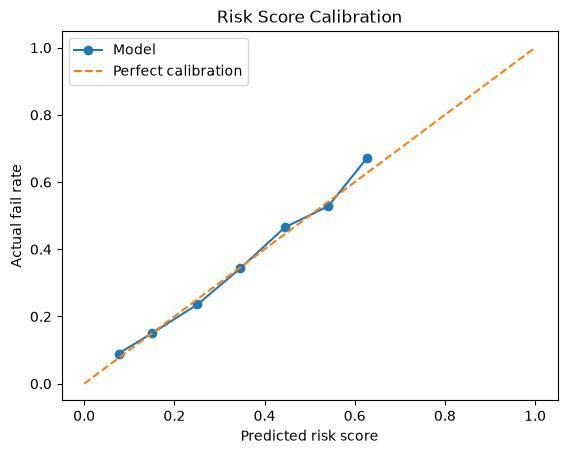

0.02409505815374957 0.6616494418449106


In [24]:
# risk score calibration plot

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

y_test_binary = (y_test_lt5 == "fail").astype(int) # get actual fail rate
prob_true, prob_pred = calibration_curve(y_test_binary, risk_scores, n_bins=10) 
    # plot predicted rates vs. actual rates, grouped by bins

plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Predicted risk score")
plt.ylabel("Actual fail rate")
plt.legend()
plt.title("Risk Score Calibration")
plt.show()

print(risk_scores.min(), risk_scores.max())

-> a relatively close fit seen - some observations based on the plot:

- Only **7** points are shown, not the **10** total (one for each bin). This is because `calibration_curve` splits the full **0-1** range into 10 equal-width bins, but only plots bins with at least one establishment. The underlying risk scores range from **2.4%** to **66.2%** (confirmed above), meaning only 7 of the 10 equal-width bins (0.0–0.7) contain any establishments - the top three (0.7–1.0) are empty and therefore not plotted.

- The highest bin (predicted **~0.63**) shows an actual fail rate running notably higher (**0.68**) than predicted - this is the point sitting furthest from the actual diagonal. What this suggests is that the model is **slightly under-confident at the top end**, i.e. the highest-risk establishments are in fact even riskier than the predictions. The practical implication is that where establishments are flagged as high risk, their risk score should be treated as a _floor_ rather than a precise ceiling. 

Happy with the overall performance shown, I will now _re-train_ the `risk_model` on the **full dataset** (no data held back for testing):

In [25]:
# re-train risk model on full dataset:

X_full_lean = X_full  # already excludes crime_decile, from the final model retrain step
risk_model_final = LogisticRegression(max_iter=1000, random_state=42)
risk_model_final.fit(X_full_lean, y_full)

print(f"Trained on {len(X_full_lean)} rows.")

Trained on 63409 rows.


### Save fitted models:

Lastly, I'll save the two fitted models with `joblib` so that they can persist and can be re-loaded later, without the need to retrain:

In [26]:
# save final fitted models:

import joblib
import os
import json

os.makedirs("../models", exist_ok=True)

joblib.dump(final_model, "../models/fhrs_classifier.joblib")
joblib.dump(risk_model_final, "../models/fhrs_risk_scorer.joblib")

# ensure features are stored exactly as there were when used for training
feature_columns = X_full.columns.tolist()
with open("../models/feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)

print(f"Saved 2 models and {len(feature_columns)} feature columns.")

Saved 2 models and 44 feature columns.


-> I will also capture and save key facts about both models:

In [ ]:
# key model 'facts card':

model_card = {
    "target": "FHRS rating < 5 (fail) vs 5 (pass)",
    "features": feature_columns,
    "classifier": {
        "type": "LogisticRegression, class_weight='balanced'",
        "test_set_metrics": {"accuracy": 0.63, "fail_f1": 0.55, "pass_f1": 0.69},
    },
    "risk_scorer": {
        "type": "LogisticRegression, unweighted (for calibrated probabilities)",
        "calibration_note": "Well-calibrated across observed 0.08-0.54 range; mild under-confidence above ~0.6",
    },
    "trained_on_rows": len(X_full),
    "known_limitations": (
        "Poor separation of critical (<=2*) ratings across every approach tested "
        "(three-tier, binary, ordinal, oversampled). Available features (deprivation "
        "deciles, business type, borough) appear insufficient for this specific distinction."
    ),
}

with open("../models/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2)

print("Model card saved.")

Model card saved.


Once complete, one final step before moving on to the output notebook is to store and check the 'rare' business type grouping - ensuring this is kept consistent between workbooks is critical to avoid drift/mismatches in ouput data. 

In [ ]:
# store record holding BusinessType categories classed as 'rare' 
    # these were collapsed and grouped into 'Other' for modelling
with open("../models/business_type_grouping.json", "w") as f:
    json.dump(rare_types, f, indent=2)

# check saved info
print(f"Saved {len(rare_types)} rare categories: {rare_types}")

Saved 3 rare categories: ['Distributors/Transporters', 'Farmers/growers', 'Importers/Exporters']
